## OCR Nedir ?

OCR - Optical Character Recognition -: piksellerden oluşan bir görüntüyü, makinenin işleyebileceği mente çeviren teknolojidir.

Biz maç yayınlarında bulunan scoreboard'ı OCR yardımıyla bilgisayarın işlemesini sağlayacağız.

OCR yöntemlerine ne ilkelden en modern yöntemlere doğru inceleyelim.

 1. Template Matching - En Temel Fikir: Şablon Eşleştirme

Temelde bu yöntem, bilgisayarlı görünün (computer vision) brute-force dönemidir. Görüntüyü bir özellikler bütünü olarak değil, sadece bir piksel matrisi (grid) olarak görür.. Her karakterin bir referans görüntüsü vardır(template). Okunacak pixelleri her template karşılaştırır, en çok benzeyeni seçer.

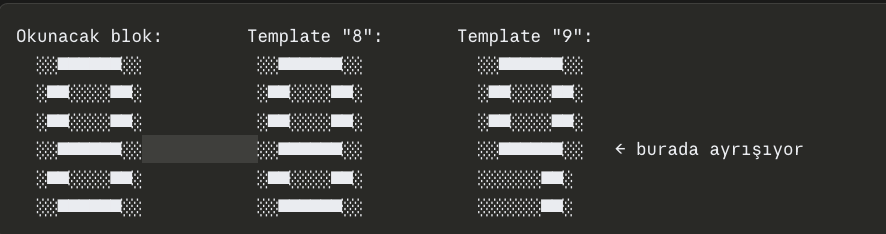


Her template ile pixel örtüşmeyi ölçer ve en çok benzerlik vereni verir.

Peki benzerlik nasıl ölçülür ? İki görüntüyü vektör olarak düşünürsek, aralarındaki farkı hesaplarız. (pixel - wise squared difference veya normalized cross-correlation). Yani iki şey birbirine ne kadar benziyor ona bakarız.

Fakat:
  - Font değişirse template tutmaz. (örn kavisli 9 ve köşeli 9)
  - Boyut değişirse hizalama bozulur
  - 1 - 2 pixel kayma bile örtüşmeyi mahveder.
  - Arka plan gürültülüyse skor kirlenir.

Yani, bu yöntemin en büyük problemi değişmezlik yeteneğinin sıfır olmasıdır.

  2. Classical Feature-Based

Bu aşama, computer vision dünyasında piksellere bakmayı bırakıp, nesnenin karakterini anlamaya çalışılan çağdır.

Template matching sorunu ham pixelleri karşılaştırıyordu ve bu yüzden çok kırılgandı. Burada ise pixellerden ziyade, karakterin daha somut özellikleri karşılaştırılır.

Bu yöntemin felfesi şudur: İnsan beyni 8 rakamını tanırken şu piksek siyah bu beyaz demez. Üst üste binmiş 2 yuvaralak vardır der. O halde makineye de bu kavramları öğretir.


Bu mimari 2 aşamadan oluşur:
  - Feature Extraction: Topolojik ve yapısal özellikler olarak düğüm noktaları, uç noktalar, loop sayıları v.s. bakılır. Ayrıca istatiksel ve gradyan tabanlı özellikler olarak ise piksellerin renklerine değil, kenarların hangi yöne doğru eğilimli olduğuna bakılır. Burada istatiksel yöntemler yapısalla göre daha dayanıklıdır

  - Classification: Sınıflandırıcılar karar mekanizmalarıdır. Elde ediline örn. 64 boyutlu feature vectır, artık görüntüden bağımsız bir sayı dizisidir. Bu sayı dizisi, klasik makine öğrenmesi algoritmalarına beslenir. SVM (Support Vector Machine), kNN, random forest gibi.


Peki neden Template matching'ten iyidir ? Feature'ler tasarımca varyasyona dayanıklıdır. Örn. kapalı döngü sayısı değişse bile 8 hep iki kalır. Yani küçük font v.s. değişikliklerine dayanıklıdır.

Fakat, Modelin zekası mühendisin harfi tanımlama yeteneği ile sınırlıdır. İnsanlar her türlü bozuk el yazısını, her türlü gürültülü arka planı kapsayacak matematiksel kuralları (featrue) elle yazamaz. Yani özellik uzayı çok karmaşıklaştığında insan tasarımı yetersiz kalır.

  3. Classical OCR Engines - Tesseract

Tesseract, yukarıdaki fikirleri paketleyip kullanıma hazır motor haline getiren bir yapıların en bilinenidir. Tesseract'ın 2 farklı modu vardır:

  - Legacy mod: Eski olan yaklaşımdır. Karakterleri tek tek segment eder, feature çıkarır ve sınıflandırır. Kelime kelime, karakter karakter çalışır.
  
  - LSTM Mod: Deep learning tabanlı yeni bir motordur. satırı bir sıra olarak okur. Modern Tesseract bunu kullanır.

Tesseract'e bir görüntü veririz, bize bir string döner. Denenebilir!

  4. Deep Learning OCR - modern way

Buradaki büyük fikir değişimi, detection ve recognition ayrı ayrı öğrenilmiş modellerle yapılır. Ve recognition'u karakter karakter değil, sıra olarak ele alır.

Bu yöntem de 2 alt parca var:

a. Detection - metin nerede ?

Görünteki metni CNN tabanlı modeller bulur (east, DBNet, Craft gibi). Yani bir görüntü verirsin, sana şurada metin var olarak bounding box'lar döndürür. Biz ekstra olarak metin tarama yapmayacağımız için gereksiz.

b. Recognition - metin de ne yazıyor ?

Modern recognition metni tek tek karakterlere bölmek yerine, satırı soldan sağa doğru bir dizi olarak okur. Peki neden ?

Çünkü karakterleri kesin sınırlara ayırmak (segmentation) başlı başına zor ve hataya açıktır. Bitişik yazı, benzer harfler v.s. Deep learning ise bunu şöyle çözer:

  - CRNN + CTC yaklaşımı(klasik deep OCR mimarisi):
    - CNN: görüntüden feature çıkarır.

    - RNN/LSTM: Bu feature'ları soldan sağa bir sekans olarak işler. - Once 9 gördüm, sonra iki nokta, sonra 0 gibi.

    - CTC (Connectionist Temporal Classification): Karakterleri önceden hizalamak zorunda kalmadan, değişken uzunlukta çıktı üretmeyi sağlayan akıllı bir kayıp fonksiyonudur.

    
